In [45]:
import pynini
from pynini.lib import pynutil
import graphviz
from typing import *

In [ ]:
consonants = "ptkbdgmn"
vowels = "aeiouə"

symbols = pynini.SymbolTable()
symbols.add_symbol('<eps>')
for phone in consonants+vowels:
    symbols.add_symbol(phone)
# symbols.add_symbol('EOS')
# symbols.add_symbol('BOS')

In [61]:
fsa = lambda s: pynini.accep(' '.join(s), token_type=symbols)

def set_symbols(fst: pynini.Fst):
    fst.set_input_symbols(symbols)
    fst.set_output_symbols(symbols)
    return fst

In [53]:
def print_fst(f):
    f=set_symbols(f)
    tmp_path = 'tmp.dot'
    f.draw(tmp_path, portrait=True)
    with open(tmp_path) as file:
        return graphviz.Source(file.read())

In [39]:
C = pynini.union(*consonants)
V = pynini.union(*vowels)
Sigma = C|V
SigmaStar = pynini.closure(Sigma)

insert_wordfinal_schwa = pynini.cdrewrite(
    tau=pynutil.insert('ə'),
    l='p',
    r='t',
    sigma_star=SigmaStar
)

apply_rule = lambda s, f: (s@f).string()

apply_rule("pt", insert_wordfinal_schwa)

'pət'

In [ ]:
C = pynini.union(*[
    fsa(consonant) for consonant in consonants
])
V = pynini.union(*[
    fsa(vowel) for vowel in vowels
])

Sigma = C|V
SigmaStar = pynini.closure(Sigma)

insert_wordfinal_schwa = pynini.cdrewrite(
    tau=pynutil.insert(fsa('ə')),
    l=fsa('p'),
    r='[EOS]',
    sigma_star=SigmaStar
)

apply_rule = lambda s, f: (fsa(s)@f).string(token_type=symbols).replace(' ', '')
apply_rule("p", insert_wordfinal_schwa)

'pə'

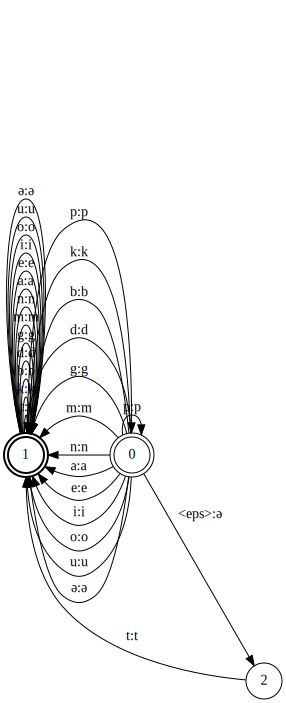

In [54]:
print_fst(insert_wordfinal_schwa)